In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)
from ISLP import confusion_table
from ISLP.models import contrast

In [3]:
from sklearn.discriminant_analysis import (\
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [11]:
import seaborn as sns

### Auto Dataset

In [4]:
Auto = load_data('Auto')
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


### (a)

In [5]:
mpg_median = np.median(Auto['mpg'])
mpg_median

np.float64(22.75)

In [6]:
mpg01 = (Auto['mpg'] >= mpg_median)
mpg01

name
chevrolet chevelle malibu    False
buick skylark 320            False
plymouth satellite           False
amc rebel sst                False
ford torino                  False
                             ...  
ford mustang gl               True
vw pickup                     True
dodge rampage                 True
ford ranger                   True
chevy s-10                    True
Name: mpg, Length: 392, dtype: bool

In [7]:
Auto['mpg01'] = mpg01

In [8]:
Auto = Auto.reset_index()

### (b)

In [9]:
Auto

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,False
1,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,False
2,plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,False
3,amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,False
4,ford torino,17.0,8,302.0,140,3449,10.5,70,1,False
...,...,...,...,...,...,...,...,...,...,...
387,ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,True
388,vw pickup,44.0,4,97.0,52,2130,24.6,82,2,True
389,dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,True
390,ford ranger,28.0,4,120.0,79,2625,18.6,82,1,True


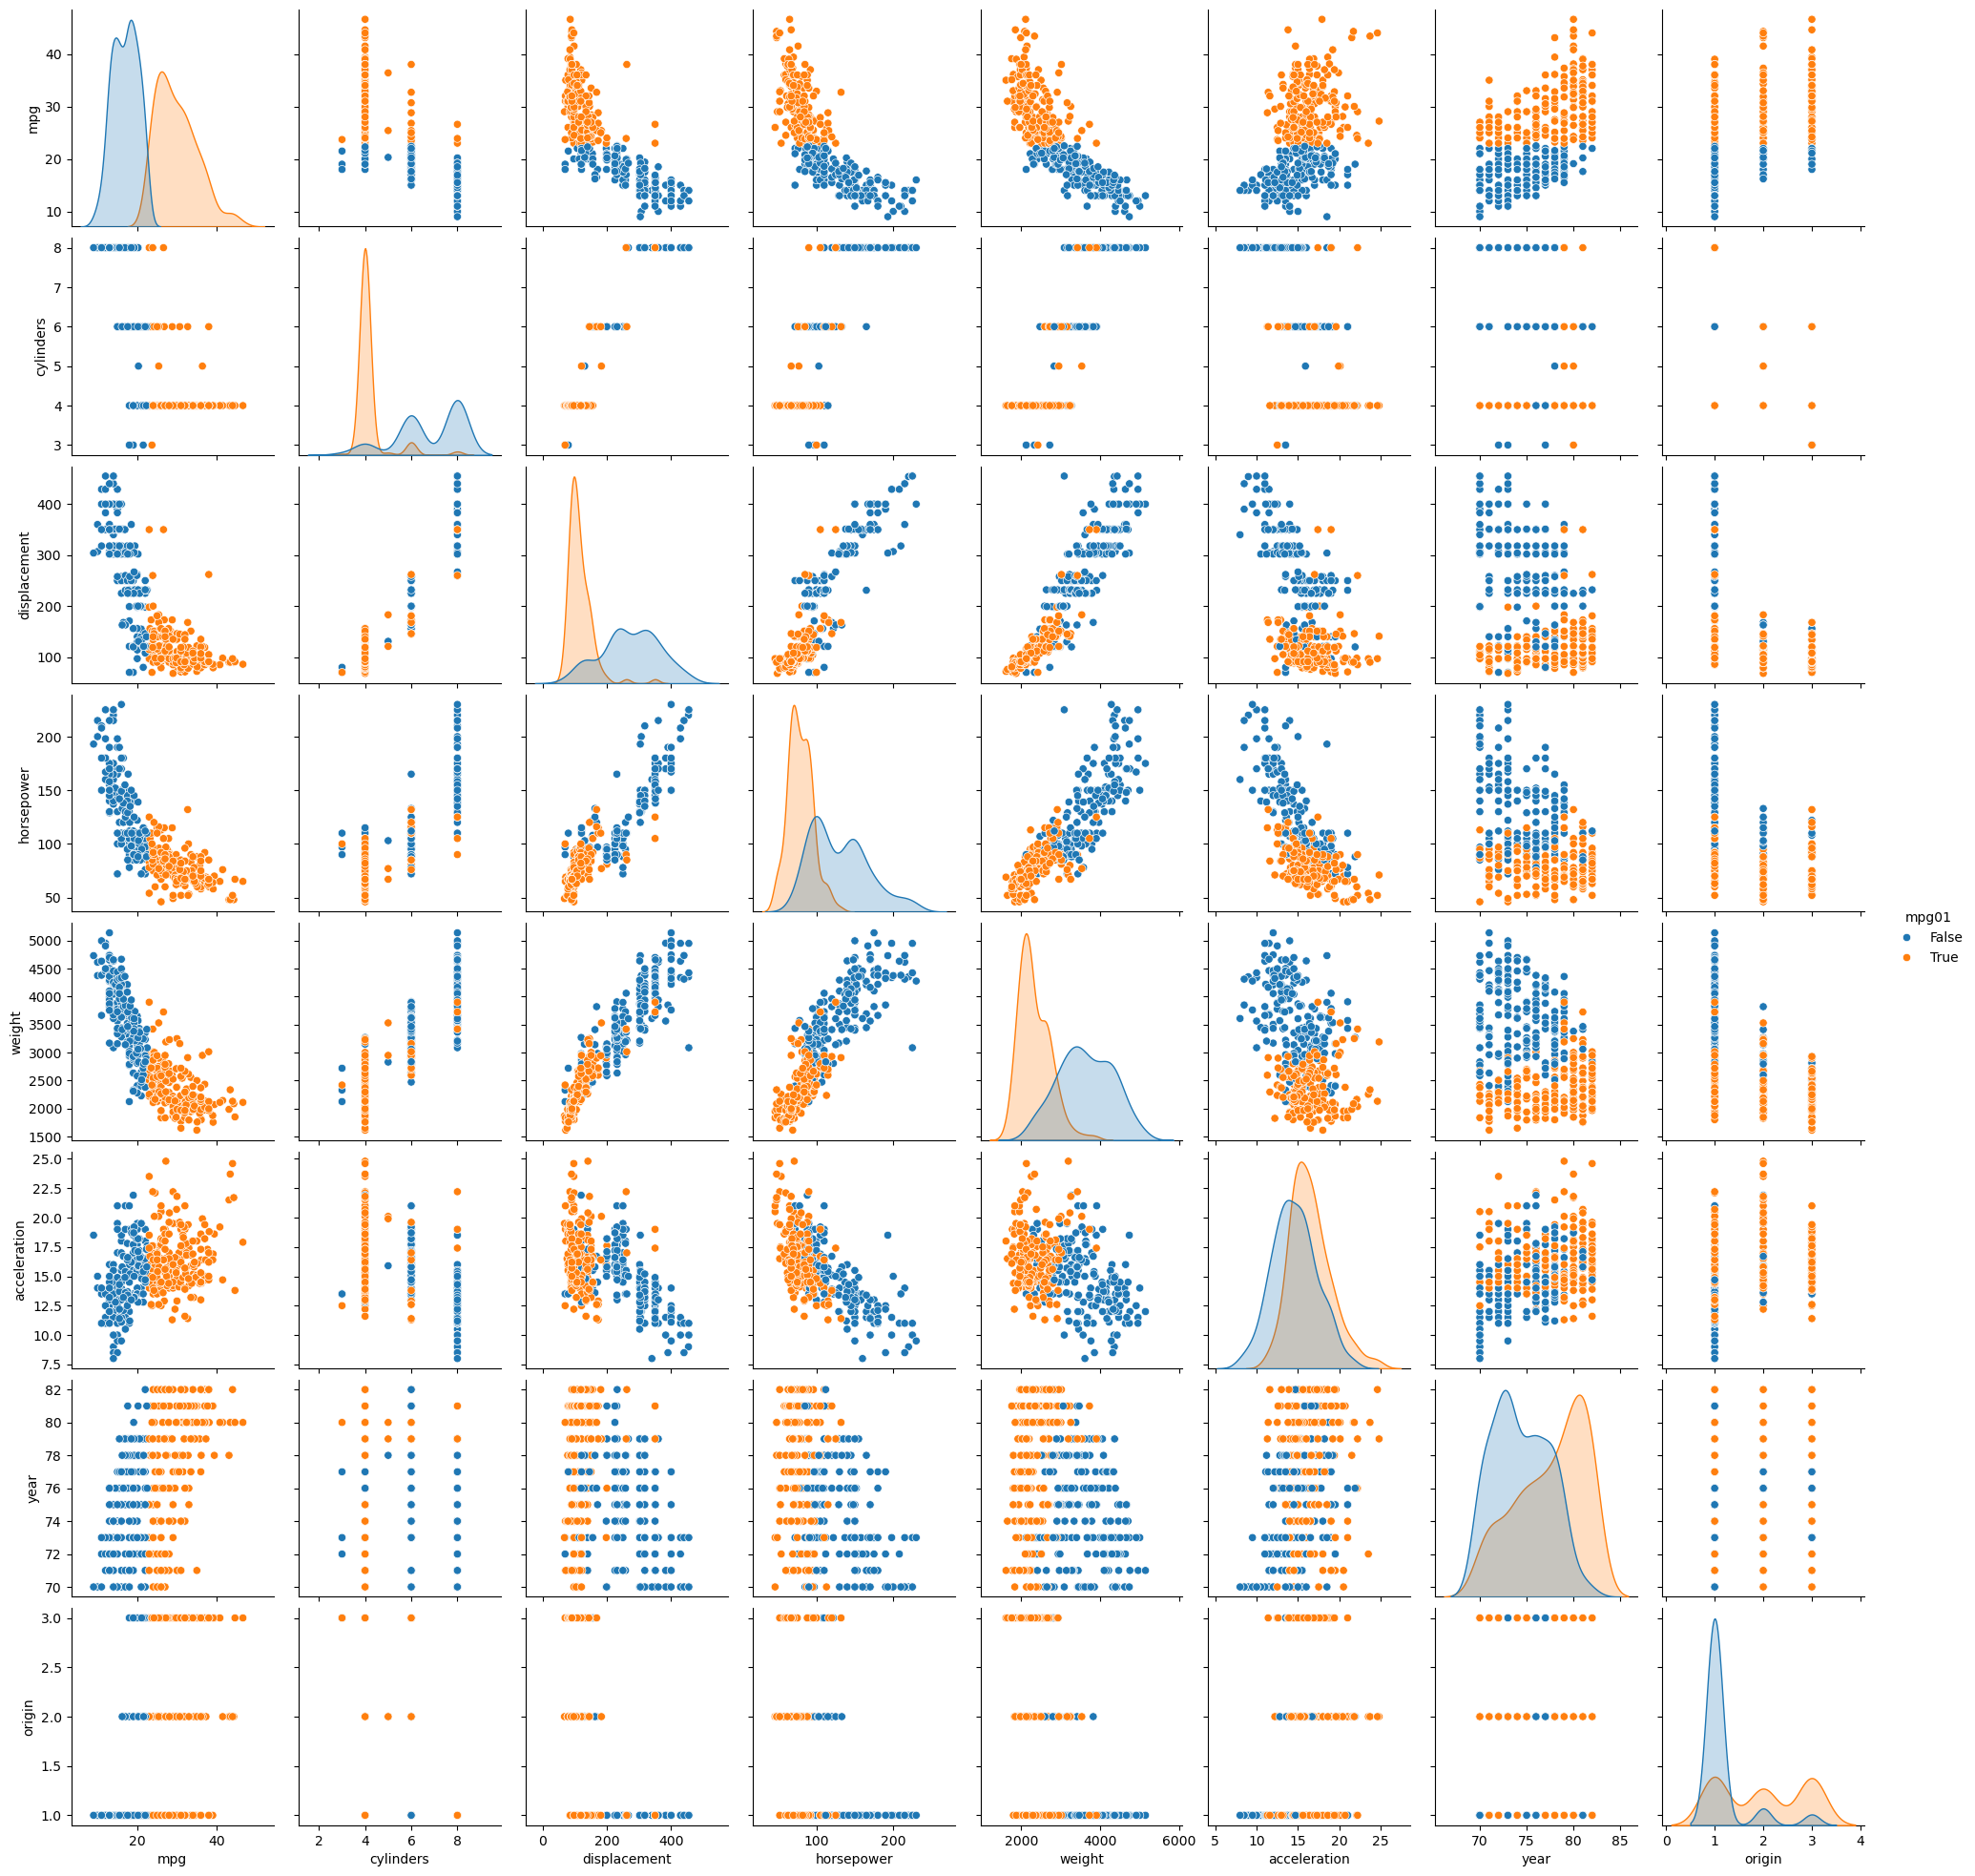

In [12]:
sns.pairplot(Auto, hue='mpg01')

In [13]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


From the graph and correlation matrix it seems like mpg01 has very strong correlation with cylinders, displacement, horsepower and weight. (with other variables like acceleration year and origin there is some good correlation)

<Axes: xlabel='mpg', ylabel='mpg01'>

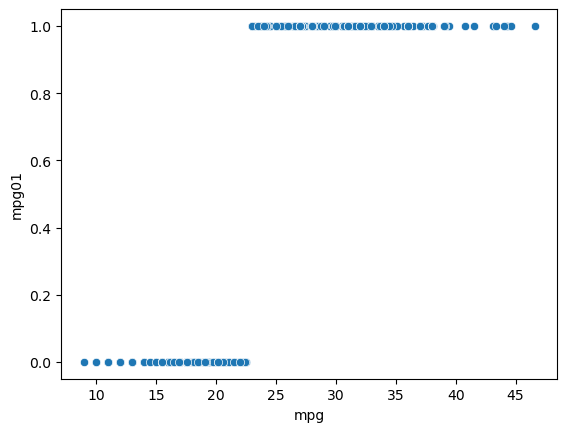

In [17]:
sns.scatterplot(data=Auto, x='mpg', y = 'mpg01')

<Axes: xlabel='cylinders', ylabel='mpg01'>

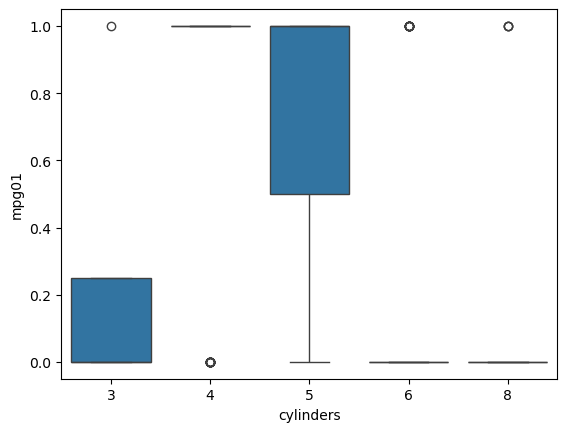

In [19]:
sns.boxplot(data=Auto, x='cylinders', y = 'mpg01')